# Audio Clustering and Figures
## Notebook Summary

This notebook applies PCA and k-means clustering to the final integrated dataset in order to identify interpretable audio archetypes among Billboard hits. Cluster composition, genre distributions, chart outcomes, and temporal trends are analyzed to investigate how successful songs have changed over time.

### Inputs

* `final_df.csv`
* `final_df_FULL_BACKUP_.csv`

### Outputs

* PCA visualizations
* Audio cluster summaries
* Poster figures and summary tables

### Key Contributions

* Identify major dimensions of variation in Billboard songs using PCA.
* Develop interpretable audio archetypes through clustering and genre analysis.
* Quantify changes in audio archetype prevalence across eras.


## 0) Setup

- Load the final merged dataset from the audio feature extraction notebook.
- Create era labels used for pre- versus post-TikTok comparisons.
- Prepare the dataset for PCA, clustering, and final visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("../data/final/final_df_FULL_BACKUP.csv")

print(df.shape)
df.head()

(4078, 84)


,Song,Artist,first_chart_date,last_chart_date,entry_rank,peak_rank,total_weeks,top10_weeks,top40_weeks,avg_rank,...,genre_family_reggae,genre_family_rock,genre_family_stage_and_screen,audio_feature_error,preview_file,tempo_bpm_raw,tempo_bpm_adjusted,tempo_adjustment_reason,days_release_to_chart,days_release_to_peak
0,"""1 Step Forward, 3 Steps Back""",Olivia Rodrigo,2021-06-02,2021-06-23,19,19,4,0,2,54.250000,...,0.005238,0.152280,0.011177,NaN,preview_clips/olivia_rodrigo__1_step_forward_3...,172.265625,86.132812,halved_145_180_likely_double_time,11.0,11.0
1,"""1, 2 Step""",Ciara Featuring Missy Elliott,2005-01-05,2005-07-20,2,2,39,12,24,19.448276,...,0.003168,0.007899,0.000968,NaN,preview_clips/ciara_featuring_missy_elliott__1...,116.173401,116.173401,unchanged,-6639.0,-6639.0
2,"""1, 2, 3, 4""",Plain White T's,2009-02-04,2009-06-17,91,34,20,0,5,47.800000,...,0.023637,1.199483,0.002437,NaN,preview_clips/plain_white_t_s__1_2_3_4__160588...,89.632843,89.632843,unchanged,133.0,238.0
3,"""10,000 Hours""",Dan + Shay & Justin Bieber,2019-10-16,2020-05-06,4,4,30,14,28,15.933333,...,0.016751,0.140071,0.005422,NaN,preview_clips/dan_shay_justin_bieber__10_000_h...,178.205811,178.205811,kept_high_bpm_strong_electronic_or_rock,11.0,11.0
4,"""Awful, Beautiful Life""",Darryl Worley,2005-01-05,2005-03-23,49,30,20,0,2,63.583333,...,0.000909,0.723153,0.004464,NaN,preview_clips/darryl_worley__awful_beautiful_l...,112.451279,112.451279,unchanged,369.0,383.0


## 1) Audio Feature Selection

- Select the final audio features used for PCA and clustering.
- Remove rows with missing feature values.
- Create the analysis matrix for unsupervised audio modeling.

In [ ]:
audio_features = [
    "valence",
    "arousal",
    "rms_loudness",
    "spectral_centroid_mean",
    "spectral_rolloff_mean",
    "tempo_bpm_adjusted"
]

audio_df = df.dropna(subset=audio_features + ["audio_era"]).copy()

print(audio_df.shape)
audio_df[audio_features].describe()

(3783, 87)


,valence,arousal,rms_loudness,spectral_centroid_mean,spectral_rolloff_mean,tempo_bpm_adjusted
count,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000
mean,5.544947,5.413702,0.285484,3067.652864,1460.757346,108.876222
std,0.871908,0.612435,0.069904,738.435728,657.988666,23.781746
min,2.801376,3.354244,0.023428,783.284465,108.500636,59.921703
25%,4.868063,5.031533,0.244441,2554.178034,1005.068922,88.773232
50%,5.535745,5.393561,0.287628,3057.588934,1381.541646,106.933563
75%,6.198899,5.799356,0.328454,3533.251962,1832.674487,128.058739
max,8.724963,7.804921,0.567119,7044.185195,10154.975132,178.205811


## 2a) Audio PCA

- Standardize audio features before dimensionality reduction.
- Use PCA to summarize major dimensions of audio variation.
- Store PC1 and PC2 for visualization and cluster interpretation.

In [ ]:
scaler = StandardScaler()

X_audio = audio_df[audio_features]
X_audio_scaled = scaler.fit_transform(X_audio)

In [ ]:
audio_pca = PCA(n_components=2)

audio_pcs = audio_pca.fit_transform(X_audio_scaled)

audio_df["audio_PC1"] = audio_pcs[:, 0]
audio_df["audio_PC2"] = audio_pcs[:, 1]

print("PC1 explained:", round(audio_pca.explained_variance_ratio_[0] * 100, 2), "%")
print("PC2 explained:", round(audio_pca.explained_variance_ratio_[1] * 100, 2), "%")
print("Total explained:", round(audio_pca.explained_variance_ratio_.sum() * 100, 2), "%")

PC1 explained: 43.36 %
PC2 explained: 18.74 %
Total explained: 62.1 %


## 2b) PCA Interpretation

- Examine feature loadings to determine which audio characteristics contribute most strongly to each principal component.
- Use loadings to interpret the major dimensions of variation in Billboard songs.
- Support later cluster interpretation using the reduced PCA space.

The first principal component (PC1) was driven primarily by spectral brightness and emotional energy. High positive loadings were observed for spectral centroid (0.531), valence (0.501), spectral rolloff (0.491), and arousal (0.445), indicating that songs with high PC1 scores tended to be brighter, more energetic, and more emotionally positive. This dimension largely separated energetic crossover songs from darker and more subdued recordings.

The second principal component (PC2) was dominated by loudness and tempo. RMS loudness exhibited the strongest loading (0.755), followed by tempo (0.381), suggesting that PC2 captured differences in rhythmic intensity, production energy, and dance-oriented characteristics. Songs with high PC2 scores tended to be louder, faster, and more rhythmically driven, while lower-scoring songs generally exhibited less production intensity and a more relaxed musical character.

Together, the two principal components suggest that much of the variation among Billboard hits can be explained by two broad dimensions: (1) brightness and emotional energy, and (2) rhythmic intensity and production-driven momentum.

In [ ]:
audio_loadings = pd.DataFrame(
    audio_pca.components_.T,
    index=audio_features,
    columns=["audio_PC1", "audio_PC2"]
)

audio_loadings.round(3)

,audio_PC1,audio_PC2
valence,0.501,0.251
arousal,0.445,0.163
rms_loudness,0.038,0.755
spectral_centroid_mean,0.531,-0.162
spectral_rolloff_mean,0.491,-0.412
tempo_bpm_adjusted,0.161,0.381


## 3) Audio Clustering

- Evaluate candidate cluster counts using k-means diagnostics.
- Fit the final three-cluster model used for audio archetypes.
- Attach cluster labels back to each song for interpretation.

In [ ]:
for k in range(2, 8):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_audio_scaled)
    score = silhouette_score(X_audio_scaled, labels)

    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.245
k=3, silhouette=0.200
k=4, silhouette=0.182
k=5, silhouette=0.186
k=6, silhouette=0.183
k=7, silhouette=0.176


In [ ]:
audio_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

audio_df["audio_cluster"] = audio_kmeans.fit_predict(X_audio_scaled)

audio_df["audio_cluster"].value_counts().sort_index()

audio_cluster
0    1720
1    1416
2     647
Name: count, dtype: int64

In [ ]:
audio_cluster_summary = (
    audio_df
    .groupby("audio_cluster")[audio_features]
    .mean()
    .round(2)
)

audio_cluster_summary

,valence,arousal,rms_loudness,spectral_centroid_mean,spectral_rolloff_mean,tempo_bpm_adjusted
audio_cluster,,,,,,
0,6.19,5.81,0.28,3589.86,1898.10,115.55
1,5.14,5.23,0.33,2794.71,1120.54,101.13
2,4.70,4.78,0.20,2276.75,1042.69,108.08


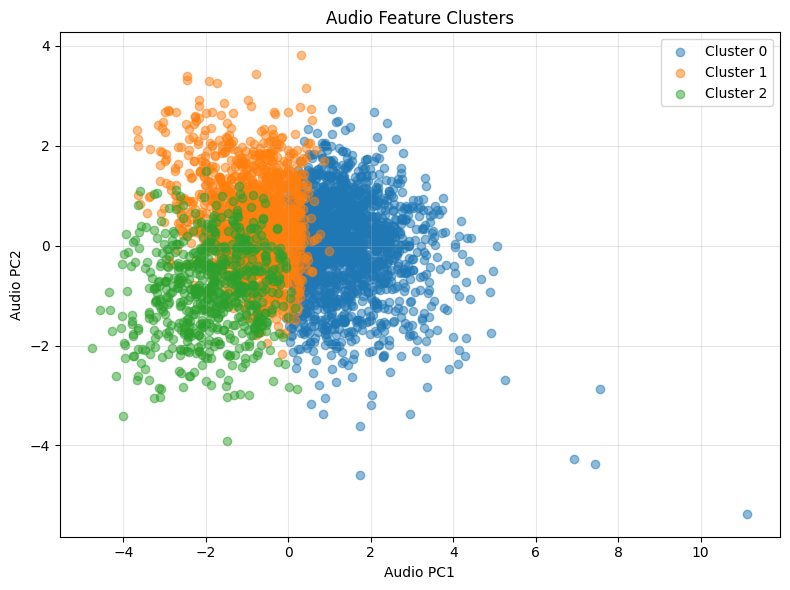

In [ ]:
cluster_colors = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green"
}

plt.figure(figsize=(8, 6))

for cluster in sorted(audio_df["audio_cluster"].unique()):
    subset = audio_df[audio_df["audio_cluster"] == cluster]

    plt.scatter(
        subset["audio_PC1"],
        subset["audio_PC2"],
        color=cluster_colors[cluster],
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Audio PC1")
plt.ylabel("Audio PC2")
plt.title("Audio Feature Clusters")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
audio_era_cluster_counts = pd.crosstab(
    audio_df["audio_era"],
    audio_df["audio_cluster"]
).loc[["Pre TikTok", "Post TikTok"]]

audio_era_cluster_counts

audio_cluster,0,1,2
audio_era,,,
Pre TikTok,1186,593,315
Post TikTok,534,823,332


In [ ]:
audio_era_cluster_pct = (
    pd.crosstab(
        audio_df["audio_era"],
        audio_df["audio_cluster"],
        normalize="index"
    ) * 100
).loc[["Pre TikTok", "Post TikTok"]]

audio_era_cluster_pct.round(1)

audio_cluster,0,1,2
audio_era,,,
Pre TikTok,56.6,28.3,15.0
Post TikTok,31.6,48.7,19.7


In [ ]:
# Audio features to compare across eras
feature_cols = [
    "valence",
    "arousal",
    "rms_loudness",
    "spectral_centroid_mean",
    "tempo_bpm_adjusted"
]

# Calculate era means
feature_summary = (
    audio_df
    .groupby("audio_era")[feature_cols]
    .mean()
    .T
)

# Force order
feature_summary = feature_summary[["Pre TikTok", "Post TikTok"]]

# Calculate percent change
feature_summary["% Change"] = (
    (feature_summary["Post TikTok"] - feature_summary["Pre TikTok"])
    / feature_summary["Pre TikTok"]
    * 100
).round(1)

# Run Mann-Whitney tests for each feature
p_values = []

for feature in feature_cols:
    pre = audio_df.loc[audio_df["audio_era"] == "Pre TikTok", feature].dropna()
    post = audio_df.loc[audio_df["audio_era"] == "Post TikTok", feature].dropna()

    u, p = mannwhitneyu(pre, post, alternative="two-sided")
    p_values.append(p)

feature_summary["p-value"] = p_values

# Clean feature names for display
feature_summary = feature_summary.rename(index={
    "valence": "Valence",
    "arousal": "Arousal",
    "rms_loudness": "Loudness",
    "spectral_centroid_mean": "Brightness",
    "tempo_bpm_adjusted": "Tempo"
})

display(feature_summary.round(3))

audio_era,Pre TikTok,Post TikTok,% Change,p-value
Valence,5.749,5.292,-8.0,0.000
Arousal,5.478,5.334,-2.6,0.000
Loudness,0.275,0.298,8.3,0.000
Brightness,3231.770,2864.182,-11.4,0.000
Tempo,110.016,107.463,-2.3,0.001


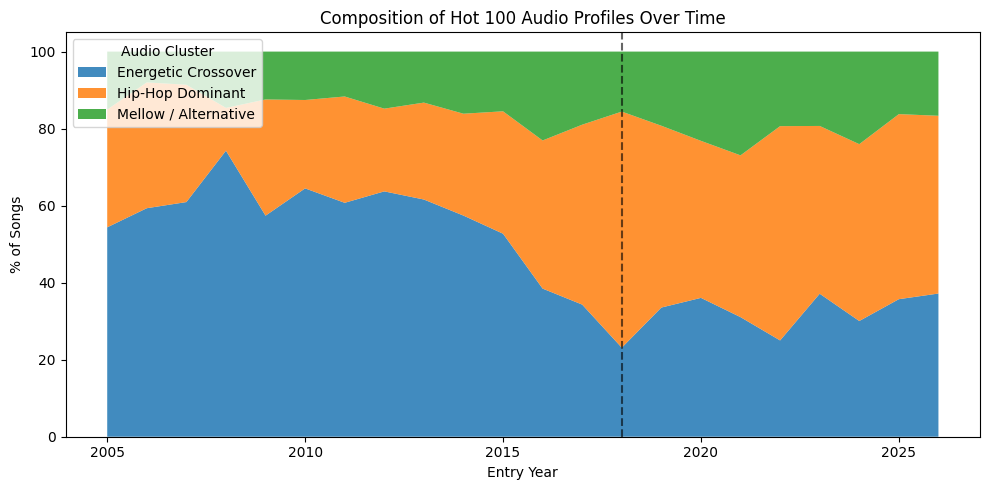

In [ ]:
cluster_pct_year = (
    pd.crosstab(
        audio_df["entry_year"],
        audio_df["audio_cluster"],
        normalize="index"
    ) * 100
)

cluster_pct_year = cluster_pct_year.rename(columns={
    0: "Energetic Crossover",
    1: "Hip-Hop Dominant",
    2: "Mellow / Alternative"
})

plt.figure(figsize=(10,5))

plt.stackplot(
    cluster_pct_year.index,
    cluster_pct_year["Energetic Crossover"],
    cluster_pct_year["Hip-Hop Dominant"],
    cluster_pct_year["Mellow / Alternative"],
    labels=cluster_pct_year.columns,
    alpha=0.85
)

plt.axvline(
    2018,
    linestyle="--",
    color="black",
    alpha=0.6
)

plt.title("Composition of Hot 100 Audio Profiles Over Time")
plt.xlabel("Entry Year")
plt.ylabel("% of Songs")

plt.legend(
    title="Audio Cluster",
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 4) Genres

- Examine genre-family distributions within each audio cluster.
- Identify which genres are most strongly associated with each archetype.
- Use genre composition to support qualitative cluster interpretation.

In [ ]:
genre_cols = [
    c for c in audio_df.columns
    if c.startswith("genre_family_")
]

cluster_genres = (
    audio_df
    .groupby("audio_cluster")[genre_cols]
    .mean()
    .T
    .round(3)
)

display(cluster_genres)

audio_cluster,0,1,2
genre_family_blues,0.008,0.008,0.038
genre_family_brass_and_military,0.001,0.000,0.001
genre_family_children_s,0.003,0.002,0.011
genre_family_classical,0.001,0.001,0.015
genre_family_electronic,0.619,0.341,0.405
genre_family_folk_world_and_country,0.042,0.041,0.170
genre_family_funk_soul,0.119,0.106,0.102
genre_family_hip_hop,0.388,0.963,0.317
genre_family_jazz,0.009,0.007,0.049
genre_family_latin,0.047,0.046,0.055


In [ ]:
for cluster in cluster_genres.columns:
    print("\nCluster", cluster)
    print(cluster_genres[cluster].sort_values(ascending=False).head(5))


Cluster 0
genre_family_electronic    0.619
genre_family_rock          0.467
genre_family_hip_hop       0.388
genre_family_pop           0.288
genre_family_funk_soul     0.119
Name: 0, dtype: float64

Cluster 1
genre_family_hip_hop       0.963
genre_family_electronic    0.341
genre_family_rock          0.206
genre_family_pop           0.139
genre_family_funk_soul     0.106
Name: 1, dtype: float64

Cluster 2
genre_family_rock                      0.541
genre_family_electronic                0.405
genre_family_hip_hop                   0.317
genre_family_pop                       0.234
genre_family_folk_world_and_country    0.170
Name: 2, dtype: float64


In [ ]:
genre_by_era = (
    audio_df
    .groupby("audio_era")[genre_cols]
    .mean()
    .T
)

genre_by_era

audio_era,Post TikTok,Pre TikTok
genre_family_blues,0.009656,0.016239
genre_family_brass_and_military,0.000524,0.000729
genre_family_children_s,0.003475,0.004618
genre_family_classical,0.003628,0.003713
genre_family_electronic,0.450487,0.500649
genre_family_folk_world_and_country,0.057345,0.068733
genre_family_funk_soul,0.090092,0.128936
genre_family_hip_hop,0.751859,0.461009
genre_family_jazz,0.011523,0.017603
genre_family_latin,0.054039,0.043450


## 5) Audio Archetype Interpretation

- Examine average feature values within each cluster.
- Review representative songs and dominant genres associated with each group.
- Assign interpretable audio archetype labels based on cluster characteristics.

### Audio Archetype Interpretation

To interpret the clusters produced by k-means clustering, we examined both the average audio feature values and the dominant genre families represented within each cluster. Rather than treating clusters as purely mathematical groupings, we used their characteristic feature profiles and genre composition to develop interpretable audio archetypes.

#### Cluster 0: Energetic Crossover Hits

This cluster represented highly commercial songs that blended characteristics from multiple mainstream genres, including pop, dance, electronic, and contemporary hip-hop. These tracks generally exhibited elevated arousal, strong spectral brightness, and polished production values. The cluster reflects the modern "crossover hit" archetype: songs designed to appeal broadly across audiences and listening contexts through high energy, strong hooks, and contemporary production techniques.

#### Cluster 1: Hip-Hop Dominant

This cluster was characterized by a strong concentration of hip-hop and rap-oriented songs. Relative to the other clusters, these tracks tended to emphasize rhythmic intensity, production-driven sound design, and beat-centered song structures. The genre composition suggested that this cluster captured a distinct hip-hop ecosystem within the Billboard Hot 100, separating it from both mainstream crossover pop and more instrument-focused recordings.

#### Cluster 2: Mellow and Alternative

This cluster contained a larger proportion of alternative, singer-songwriter, folk, rock, and softer country recordings. Compared with the other clusters, these songs generally exhibited lower energy profiles and less emphasis on modern electronic production. The cluster reflected a more introspective and instrument-focused archetype centered around melody, atmosphere, and emotional expression rather than rhythmic intensity or commercial production energy.

These archetypes were derived through qualitative inspection of both cluster-level audio feature averages and genre-family distributions. By combining quantitative audio features with genre composition, the clusters were transformed into interpretable musical categories that could be used to examine how the makeup of successful Billboard songs changed across different eras.

## 6) Billboard Outcomes by Audio Cluster

- Compare chart performance metrics across audio archetypes.
- Evaluate whether clusters differ in lifespan, time-to-peak, or chart persistence.
- Connect audio cluster structure with Billboard success outcomes.

In [ ]:
audio_billboard_summary = (
    audio_df
    .groupby("audio_cluster")[
        [
            "peak_rank",
            "total_weeks",
            "top10_weeks",
            "top40_weeks",
            "time_to_peak"
        ]
    ]
    .mean()
    .round(2)
)

audio_billboard_summary

,peak_rank,total_weeks,top10_weeks,top40_weeks,time_to_peak
audio_cluster,,,,,
0,17.82,21.14,3.38,12.76,12.03
1,19.00,17.99,2.65,10.38,8.02
2,20.96,17.58,1.92,9.23,16.29


In [ ]:
for cluster in sorted(audio_df["audio_cluster"].unique()):
    print("\n" + "=" * 60)
    print(f"AUDIO CLUSTER {cluster}")
    print("=" * 60)

    display(
        audio_df[audio_df["audio_cluster"] == cluster][
            [
                "Song",
                "Artist",
                "valence",
                "arousal",
                "rms_loudness",
                "spectral_centroid_mean",
                "tempo_bpm_adjusted"
            ]
        ].sample(
            n=min(15, len(audio_df[audio_df["audio_cluster"] == cluster])),
            random_state=42
        )
    )


AUDIO CLUSTER 0


,Song,Artist,valence,arousal,rms_loudness,spectral_centroid_mean,tempo_bpm_adjusted
1463,Heart Attack,Demi Lovato,5.884053,5.805308,0.231632,4238.966850,172.265549
3578,Tombstone,Rod Wave,5.546264,5.470427,0.266422,3169.153137,84.430611
301,BOP,DaBaby,5.775549,5.494606,0.362072,3753.357481,127.034439
340,Bad Day,Daniel Powter,5.379387,5.804925,0.233370,3142.064130,140.147247
793,Cruel Summer,Taylor Swift,6.458718,5.671692,0.260883,2963.422738,85.068542
1671,I Know You Want Me (Calle Ocho),Pitbull,6.757876,5.579319,0.282817,3002.341960,126.792923
3453,The Heart Part 4,Kendrick Lamar,5.423228,5.802316,0.218903,4071.320623,97.809319
563,Break Up In A Small Town,Sam Hunt,5.756688,5.264492,0.260763,4170.062762,89.672150
3909,Who Knew,P!nk,5.468628,5.974624,0.242280,3657.008920,140.083252
2105,Loser Like Me,Glee Cast,7.646956,5.827900,0.302064,4441.976211,105.816521



AUDIO CLUSTER 1


,Song,Artist,valence,arousal,rms_loudness,spectral_centroid_mean,tempo_bpm_adjusted
2388,N.H.I.E.,21 Savage & Doja Cat,4.865159,4.985857,0.480974,1620.909680,132.048813
2675,Pink Skies,Zach Bryan,5.021434,5.047755,0.263186,2560.767171,84.624451
970,Down Bad,Taylor Swift,5.401105,5.966967,0.267660,2589.778834,79.470116
545,Boy With Luv,BTS Featuring Halsey,5.588244,5.454425,0.227866,2781.976760,118.717636
571,Bright,Echosmith,5.099182,5.149970,0.246895,2656.316046,89.980484
2297,Moment 4 Life,Nicki Minaj Featuring Drake,5.535745,5.075954,0.355638,3508.942536,98.122368
1480,Heaven,Kane Brown,4.905485,5.233827,0.247564,2520.744303,80.798622
171,Ahhh Ha,Lil Durk,3.970793,5.244531,0.370111,2705.171949,104.039421
2874,Rock Yo Hips,Crime Mob Featuring Lil Scrappy,5.555298,4.807736,0.305362,3268.242187,77.324570
125,8am In Charlotte,Drake,4.440627,4.738479,0.270456,3185.117056,78.918808



AUDIO CLUSTER 2


,Song,Artist,valence,arousal,rms_loudness,spectral_centroid_mean,tempo_bpm_adjusted
4028,You Should Probably Leave,Chris Stapleton,4.874928,5.258160,0.214124,1968.647676,91.874100
1423,Hallelujah,Matthew Schuler,4.060286,4.282128,0.180619,1914.464979,104.264351
2691,Please Come Home For Christmas,Eagles,5.032470,4.829657,0.112487,2038.744474,91.228203
2700,Poker Face,Glee Cast,4.698187,5.096776,0.125828,2307.241900,92.285156
505,Blue,Billie Eilish,5.245200,4.722973,0.300440,1543.977680,105.231026
2769,Purple Rain,Prince And The Revolution,4.818000,4.816129,0.170159,3038.283032,112.306931
1196,Florida!!!,Taylor Swift Featuring Florence + The Machine,4.573282,4.279164,0.204035,2005.533108,75.238655
876,Devil Don't Know,Morgan Wallen,4.312094,4.579465,0.182416,2025.038426,124.951683
1484,Hell At Night,BigXthaPlug Featuring Ella Langley,4.750645,5.046851,0.116181,2134.032038,75.502937
1756,I'm Yours,Jason Mraz,4.772732,5.183208,0.187415,2172.159945,75.502480


## 7) Key Findings

- PCA revealed two major dimensions of variation: brightness/emotional energy and rhythmic intensity/production momentum.
- K-means clustering identified three interpretable audio archetypes: Energetic Crossover Hits, Hip-Hop Dominant songs, and Mellow/Alternative recordings.
- The relative prevalence of these archetypes shifted across eras, suggesting changes in the composition of successful Billboard songs over time.